In [1]:
import os

# Set this to "1" to disable torch.compile globally
# os.environ["TORCH_COMPILE_DISABLE"] = "1"
import torch
import torch.nn as nn

import numpy as np
from typing import NamedTuple
import matplotlib.pyplot as plt
from scipy.stats import gamma, poisson

from models.utils import build_warmup_epochs
from models.inn import RealNVP, RealNVPSummary
from models.regressionNetwork import RegressionNetwork, train_regression_network

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
torch.set_float32_matmul_precision("high")
from tqdm import tqdm
import torch.nn.utils as utils

In [2]:
dataset = np.load("dataset.npz")

seed = 67
print(dataset)
foot = dataset["foot"]

com_trace = dataset["com"]
com = com_trace[:, com_trace.shape[1] // 2]  # get middle position

print(f"{foot.shape=}")
print(f"{com.shape=}")
print(f"{com_trace.shape=}")
# flatten foot
foot_reshape = foot.reshape((foot.shape[0], -1))  # flatten(1)?

NpzFile 'dataset.npz' with keys: foot, com, height
foot.shape=(100000, 39, 6)
com.shape=(100000, 3)
com_trace.shape=(100000, 39, 3)


0


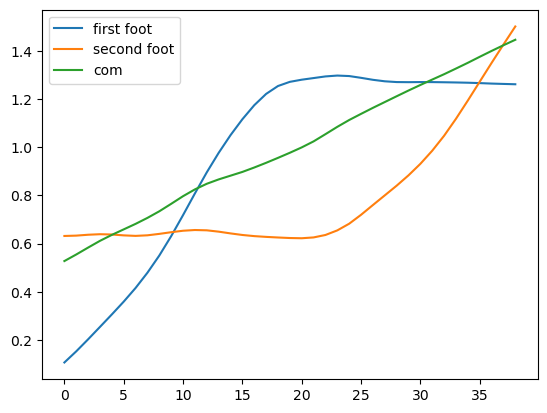

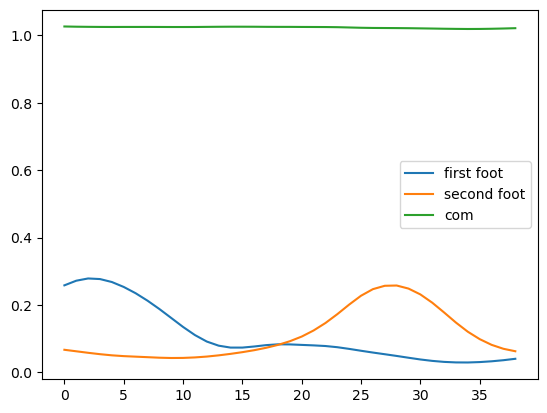

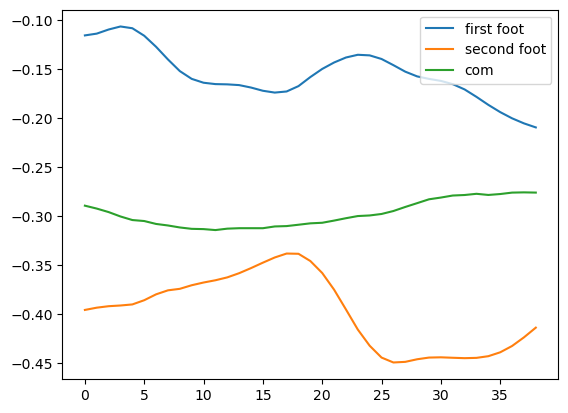

In [3]:
i_th_example = np.random.randint(0, foot.shape[1], (1,)).item()
i_th_example = 0
max_frame = 15
max_frame = foot.shape[1]
print(i_th_example)
plt.plot(foot[i_th_example, :max_frame, 0])
plt.plot(foot[i_th_example, :max_frame, 3])
plt.plot(com_trace[i_th_example, :max_frame, 0])
plt.legend(["first foot", "second foot", "com"])
plt.show()
plt.plot(foot[i_th_example, :max_frame, 1])
plt.plot(foot[i_th_example, :max_frame, 4])
plt.plot(com_trace[i_th_example, :max_frame, 1])
plt.legend(["first foot", "second foot", "com"])
plt.show()
plt.plot(foot[i_th_example, :max_frame, 2])
plt.plot(foot[i_th_example, :max_frame, 5])
plt.plot(com_trace[i_th_example, :max_frame, 2])
plt.legend(["first foot", "second foot", "com"])
plt.show()

In [4]:
print(i_th_example)

0


In [5]:
if False:
    test = foot
    for frame in range(test.shape[1]):
        plt.hist(test[:, frame, 0], bins=25)
        plt.show()
    print("-" * 89)
    print("now the other foot:")
    for frame in range(test.shape[1]):
        plt.hist(test[:, frame, 4], bins=25)
        plt.show()

In [6]:
DATASET_PATH = "dataset.npz"

SAMPLE_RATE = 50
WINDOW_SEC = 0.3
WINDOW_FRAMES = int(SAMPLE_RATE * WINDOW_SEC)


def make_windows(foot, com, W):
    """
    Converts raw foot and COM trajectories into sliding window samples.

    For each window starting at frame t:
      - foot positions are expressed relative to foot[t]
      - COM is expressed relative to the midpoint of both feet at t
      - per-sequence mean is removed to eliminate systematic bias
        between synthetic training data and real validation data

    Args:
        foot: (T, 6) array of foot positions in metres
        com:  (T, 3) array of COM positions in metres
        W:    window length in frames

    Returns:
        X: (T-W+1, W*6) input vectors
        y: (T-W+1, 3)   COM targets
    """
    frames_per_simulation = foot.shape[0]
    windows_per_simulation = frames_per_simulation - W + 1

    com_infer_frame = windows_per_simulation // 2
    # this is time moment the com will be give to the model as ground truth
    # it is also the frame the feet will be middled
    # windows_per_simulation // 2 equls the middle of each ovservation the model sees.
    # 0 wold be the begin of the movement

    foot_windows = np.lib.stride_tricks.sliding_window_view(foot, (W, 6))[:, 0]
    first_feet_first_frame = (
        foot_windows[:, com_infer_frame, :3]
    )
    average_feet_first_frame_both_feet = np.concat(
        [first_feet_first_frame, first_feet_first_frame], 1
    )
    foot_windows_start_at_0 = (
        foot_windows - average_feet_first_frame_both_feet[:, np.newaxis, :]
    )
    com_rel = (
        com[com_infer_frame : com_infer_frame + windows_per_simulation]
        - first_feet_first_frame
    )

    # TODO: change to middle of trace
    X = foot_windows_start_at_0.astype(np.float32)  # .reshape(n, -1).astype(np.float32)
    y = com_rel.astype(np.float32)
    return X, y


X, Y = make_windows(foot[0], com_trace[0], 15)


def compute_stats(path):
    """
    Estimates normalisation statistics from the dataset without loading
    everything into memory. Uses memory-mapped file access and samples
    500 simulations to compute mean and std of the windowed data.
    """
    print(f"\n{'─'*60}")
    print(f"  Step 1/3 - computing normalisation stats")
    print(f"{'─'*60}")
    print(f"  Dataset       : {path}")
    print(f"  Window        : {WINDOW_FRAMES} frames = {WINDOW_SEC*1000:.0f} ms")

    npz = np.load(path, mmap_mode="r")
    foot = npz["foot"]
    com = npz["com"]
    n_simulations, n_frames_per_sim, _ = foot.shape
    print(f"  Simulations   : {n_simulations:,}   frames/sim : {n_frames_per_sim}")

    rng = np.random.default_rng(0)
    idx = rng.choice(n_simulations, size=min(5000, n_simulations), replace=False)
    W = WINDOW_FRAMES

    foot_windows, com_windows = [], []
    for si in idx:
        X_i, y_i = make_windows(
            foot[si].astype(np.float32), com[si].astype(np.float32), W
        )
        foot_windows.append(X_i)
        com_windows.append(y_i)

    foot_all = np.concatenate(foot_windows)
    com_all = np.concatenate(com_windows)

    foot_mean = (
        foot_all.reshape((foot_all.shape[0], foot_all.shape[1], 2, 3))
        .mean((0, 1, 2))
        .astype(np.float32)
    )
    foot_mean = np.concat([foot_mean, foot_mean]).reshape(
        (1, 1, 6)
    )  # use the same for both feet
    # foot_mean = foot_all.mean(0).astype(np.float32)
    foot_std = (
        foot_all.reshape((foot_all.shape[0], foot_all.shape[1], 2, 3))
        .std((0, 1, 2))
        .astype(np.float32)
    )
    foot_std = np.concat([foot_std, foot_std]).reshape((1, 1, 6))
    # foot_std = foot_all.std(0).astype(np.float32)  + 1e-8

    com_mean = com_all.mean(0).astype(np.float32)
    com_std = com_all.std(0).astype(np.float32) + 1e-8

    print(f"  COM std       : {(com_std*100).round(1)} cm")

    return dict(
        foot_mean=foot_mean,
        foot_std=foot_std,
        com_mean=com_mean,
        com_std=com_std,
        S=n_simulations,
        T=n_frames_per_sim,
        W=W,
    )


def _sims_to_tensors(npz_foot, npz_com, indices, stats):
    """Loads simulations, builds windows and normalises."""
    W = stats["W"]
    foot_mean = np.array(stats["foot_mean"], dtype=np.float32)
    foot_std = np.array(stats["foot_std"], dtype=np.float32)
    com_mean = np.array(stats["com_mean"], dtype=np.float32)
    com_std = np.array(stats["com_std"], dtype=np.float32)

    Xs, ys = [], []
    for i in range(len(indices)):
        X_i, y_i = make_windows(
            npz_foot[indices[i]].astype(np.float32),
            npz_com[indices[i]].astype(np.float32),
            W,
        )
        Xs.append((X_i - foot_mean) / foot_std)
        ys.append((y_i - com_mean) / com_std)

        # Xs.append(X_i )
        # ys.append(y_i)

    return torch.from_numpy(np.concatenate(Xs)), torch.from_numpy(np.concatenate(ys))


stats = compute_stats(DATASET_PATH)

npz = np.load(DATASET_PATH, mmap_mode="r")
npz_foot = npz["foot"]
npz_com = npz["com"]

S = stats["S"]
W = stats["W"]
input_dim = W * 6

rng = np.random.default_rng(99)
# all_idx    = rng.permutation(S)
all_idx = np.arange(S)
split_point = int(S * 0.8)

train_pool = all_idx[:split_point]
val_idx = all_idx[split_point:]

train_Xv, train_yv = _sims_to_tensors(npz_foot, npz_com, train_pool, stats)
test_foot, test_com = _sims_to_tensors(npz_foot, npz_com, val_idx, stats)


────────────────────────────────────────────────────────────
  Step 1/3 - computing normalisation stats
────────────────────────────────────────────────────────────
  Dataset       : dataset.npz
  Window        : 15 frames = 300 ms
  Simulations   : 100,000   frames/sim : 39
  COM std       : [27.8  8.2  5.3] cm


In [7]:
print(train_Xv.shape, train_yv.shape)
print(test_foot.shape, test_com.shape)

torch.Size([2000000, 15, 6]) torch.Size([2000000, 3])
torch.Size([500000, 15, 6]) torch.Size([500000, 3])


In [8]:
print(f"{W=}")
print(X.shape, Y.shape)
print(train_Xv.shape, train_yv.shape, S * 0.8 * 25)

W=15
(25, 15, 6) (25, 3)
torch.Size([2000000, 15, 6]) torch.Size([2000000, 3]) 2000000.0


0


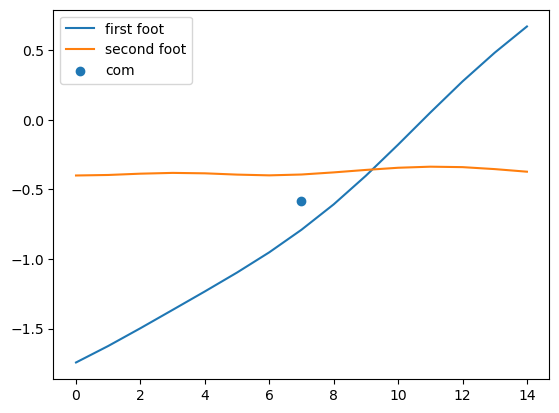

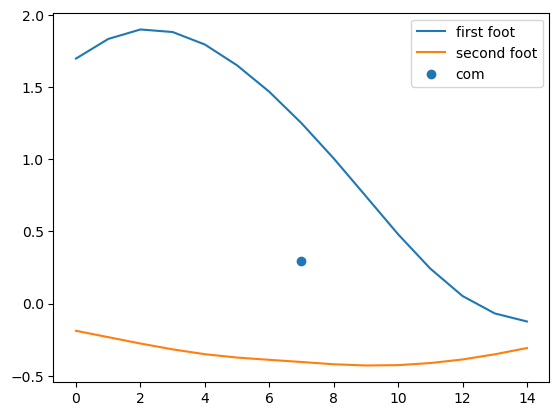

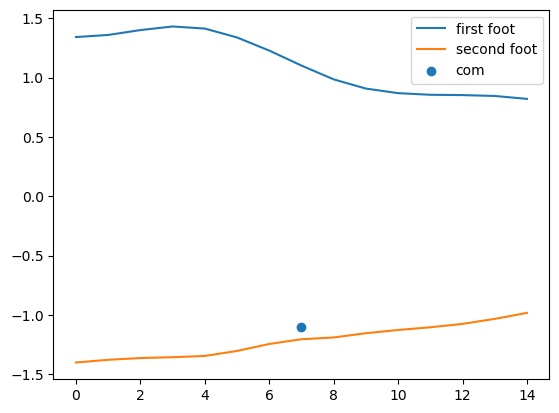

In [9]:
i_th_example = np.random.randint(0, foot.shape[1], (1,)).item()
i_th_example = 0
test = train_Xv.reshape((train_Xv.shape[0], -1, 6))
print(i_th_example)
plt.plot(test[i_th_example, :, 0])
plt.plot(test[i_th_example, :, 3])
plt.scatter([7], train_yv[i_th_example, 0])
plt.legend(["first foot", "second foot", "com"])
plt.show()
plt.plot(test[i_th_example, :, 1])
plt.plot(test[i_th_example, :, 4])
plt.scatter([7], train_yv[i_th_example, 1])
plt.legend(["first foot", "second foot", "com"])
plt.show()
plt.plot(test[i_th_example, :, 2])
plt.plot(test[i_th_example, :, 5])
plt.scatter([7], train_yv[i_th_example, 2])
plt.legend(["first foot", "second foot", "com"])
plt.show()

In [10]:
if False:
    test = train_Xv.reshape((train_Xv.shape[0], -1, 6))
    for frame in range(test.shape[1]):
        plt.hist(test[:, frame, 0], bins=25)
        plt.show()
    print("-" * 89)
    print("now the other foot:")
    for frame in range(test.shape[1]):
        plt.hist(test[:, frame, 4], bins=25)
        plt.show()

In [11]:
for frame in range(com_trace.shape[1]):
    pass
    # plt.hist(com_trace[:,frame,0],bins= 25)
    # plt.show()

In [12]:
for frame in range(foot.shape[1]):
    pass
    # plt.hist(foot[:,frame,0],bins= 25)
    # plt.show()

In [13]:
# create dataloaders:
from torch.utils.data import DataLoader, TensorDataset


train_datatensor = TensorDataset(train_yv, train_Xv.flatten(1))
test_datatensor = TensorDataset(test_com, test_foot.flatten(1))


def create_dataloaders(batch_size, num_workers=11):
    train_loader = DataLoader(
        train_datatensor,
        shuffle=True,
        batch_size=batch_size,
        num_workers=num_workers,
        pin_memory=True,
        persistent_workers=True,
        drop_last=True,  # otherwise, some instances are weighed higher
    )

    test_loader = DataLoader(
        test_datatensor,
        shuffle=False,  # unnecesarry
        batch_size=batch_size * 16,  # OPT: increase
        num_workers=max(num_workers // 2, 8),
        pin_memory=True,
        persistent_workers=True,
    )
    return train_loader, test_loader

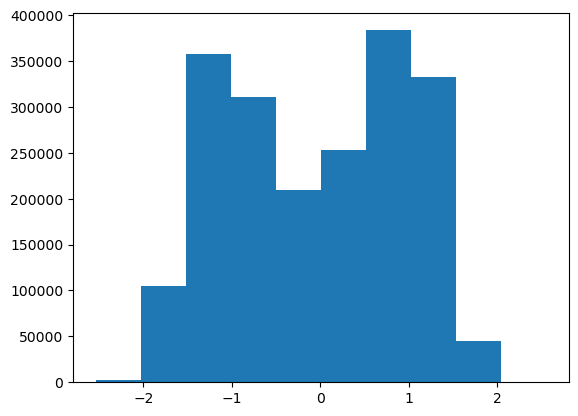

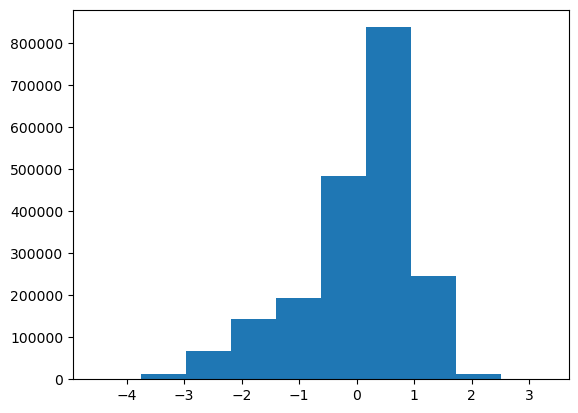

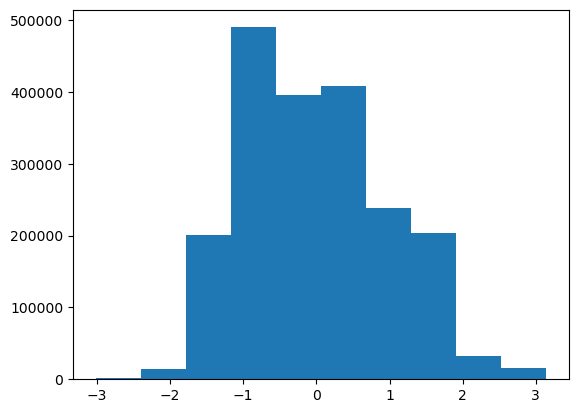

In [14]:
plt.hist(train_yv[:, 0])
plt.show()
plt.hist(train_yv[:, 1])
plt.show()
plt.hist(train_yv[:, 2])
plt.show()

torch.Size([2000000, 15, 6])


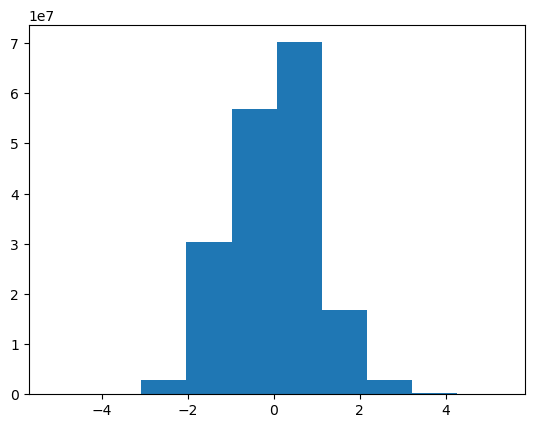

tensor([0.9388, 1.1912, 0.4638, 0.9982, 1.1978, 0.7490, 0.8814, 1.1536, 0.4495,
        1.0461, 1.2017, 0.7299, 0.8199, 1.1040, 0.4342, 1.0917, 1.1976, 0.7115,
        0.7542, 1.0414, 0.4165, 1.1343, 1.1881, 0.6938, 0.6844, 0.9653, 0.3952,
        1.1738, 1.1767, 0.6770, 0.6105, 0.8762, 0.3688, 1.2098, 1.1665, 0.6619,
        0.5327, 0.7752, 0.3375, 1.2424, 1.1601, 0.6495, 0.4509, 0.6631, 0.3006,
        1.2713, 1.1587, 0.6402, 0.3656, 0.5415, 0.2566, 1.2966, 1.1627, 0.6344,
        0.2771, 0.4121, 0.2043, 1.3179, 1.1712, 0.6326, 0.1861, 0.2773, 0.1433,
        1.3353, 1.1833, 0.6344, 0.0933, 0.1392, 0.0743, 1.3485, 1.1976, 0.6385,
        0.0000, 0.0000, 0.0000, 1.3574, 1.2127, 0.6440, 0.0928, 0.1385, 0.0751,
        1.3618, 1.2277, 0.6500, 0.1842, 0.2741, 0.1456, 1.3616, 1.2419, 0.6565])


In [15]:
print(train_Xv.shape)
plt.hist(train_Xv.flatten())
plt.show()
print(train_Xv.flatten(1).std(0))

In [16]:
# print input sizes for model
train_loader = create_dataloaders(32)[0]
com_test, foot_test = next(iter(train_loader))
print(foot_test.shape, com_test.shape)

torch.Size([32, 90]) torch.Size([32, 3])


In [17]:
from torch import GradScaler
from models.inn import CouplingBlock
from torch.profiler import profile, record_function, ProfilerActivity


def calculate_loss(output, sum_block_log_det, batch_size: int):
    log_prior = 0.5 * torch.sum(output**2, dim=1)
    log_likelihood = log_prior - sum_block_log_det
    # 3. Mean over the batch, then negative for minimization
    loss = torch.mean(log_likelihood)
    return loss


@torch.compile()
def train_step(model, X, Y, optim, scaler, batch_size):
    return


@torch.no_grad()
def test_epoch(model, test_loader, batch_size):
    model.eval()
    test_epoch_loss = torch.zeros((1,), requires_grad=False, device=device)
    test_epoch_length = len(test_loader)
    for com, foot in test_loader:
        com: torch.Tensor
        foot: torch.Tensor
        torch.compiler.cudagraph_mark_step_begin()
        X, Y = com.to(device), foot.to(device)  # TODO: nonblocking
        with torch.amp.autocast("cuda", enabled=(device.type == "cuda")):
            # print(X.shape,Y.shape)
            output, sum_block_log_det = model.forward(X, Y)
            loss = calculate_loss(output, sum_block_log_det, batch_size=batch_size)
        test_epoch_loss += loss.mean()
    test_avg_epoch_loss = (test_epoch_loss / test_epoch_length).item()
    return test_avg_epoch_loss


def train_inn_cond(
    model: RealNVP | RealNVPSummary,
    train_loader: torch.utils.data.DataLoader,
    test_loader: torch.utils.data.DataLoader,
    optim: torch.optim.Optimizer,
    scaler: GradScaler,
    lr_scheduler: torch.optim.lr_scheduler.LRScheduler,
    epochs: int,
    history,
    batch_size,
):
    """
    model: A inn
    train_set_fn: a function that returns X,Y
    with:
    X: the hidden parameter that we want a posterior for later.
    Y: the condition (like observations that will be available at inference time)

    # scaler = GradScaler("cuda", enabled=(device.type == 'cuda'))
    """
    history["train_loss"] = history.get("train_loss", [])
    history["test_loss"] = history.get("test_loss", [])
    model.train()
    pbar = tqdm(range(epochs), desc="Training", leave=True)
    for epoch in pbar:
        train_epoch_loss = torch.zeros((1,), requires_grad=False, device=device)
        train_epoch_length = len(train_loader)

        steps_per_epoch = 0
        max_steps_per_epoch = 500
        for com, foot in train_loader:
            com: torch.Tensor
            foot: torch.Tensor
            torch.compiler.cudagraph_mark_step_begin()
            X = (com+ torch.normal(0, 0.01, com.shape)).to(device, non_blocking=True) 
            Y = (foot+ torch.normal(0, 0.01, foot.shape)).to(device, non_blocking=True) 
            optim.zero_grad()
            # with torch.amp.autocast("cuda", enabled=(device.type == "cuda")):
            # print(X.shape,Y.shape)
            output, sum_block_log_det = model.forward(X, Y)
            # y is used for condition, x is input (see docstring)
            loss = calculate_loss(output, sum_block_log_det, batch_size)
            loss.backward()
            # scaler.scale(loss).backward()
            # scaler.unscale_(optim)
            # utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
            # scaler.step(optim)
            # scaler.update()
            optim.step()
            train_epoch_loss += loss.mean().detach()
            steps_per_epoch += 1
            if steps_per_epoch >= max_steps_per_epoch:
                break
                # print("LOSS: ",loss.mean().detach(),loss.shape)
        print("done train")
        train_avg_epoch_loss = (train_epoch_loss / max_steps_per_epoch).item()
        # return train_avg_epoch_loss
        model.eval()
        test_avg_epoch_loss = test_epoch(model, test_loader, batch_size=batch_size)
        model.train()

        # print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_epoch_loss:.4f}", end="\r")
        pbar.set_postfix(train_loss=train_avg_epoch_loss, test_loss=test_avg_epoch_loss)
        history["train_loss"].append(train_avg_epoch_loss)
        history["test_loss"].append(test_avg_epoch_loss)
        lr_scheduler.step()
    model.eval()
    return

In [ ]:
# TODO: normalize inputs
input_size = 3  #
observable_size = 15 * 6  # maybe use the spacial structure of the data
reduced_obs_size = 29

# model = RealNVP(
#     input_size=input_size,
#     hidden_size=hidden_size,
#     blocks=num_coup_blocks,
#     condition_size=observable_size,
# )
model = RealNVPSummary(
    input_size=input_size,
    condition_size=observable_size,
    reduced_condition_size=reduced_obs_size,
    s_hidden=256,
    s_layers=4,
    r_hidden=128,
    r_blocks=20,
)
# model = RealNVPSummary(input_size=input_size,condition_size=observable_size,reduced_condition_size=reduced_obs_size,s_hidden=256,s_layers=3,r_hidden=32,r_blocks=6)


model.to(device)
model = torch.compile(model, mode="max-autotune", fullgraph=True)

num_epochs = 50
lr_warmup_epochs = 3
init_lr = 1e-4
weight_decay = 1e-4
optimizer = torch.optim.SGD(
    model.parameters(), init_lr, fused=True
)
history = {}

batch_size = 128
train_loader, test_loader = create_dataloaders(batch_size)

scaler = torch.GradScaler("cuda", enabled=(device.type == "cuda"))
lr_scheduler = torch.optim.lr_scheduler.LambdaLR(
    optimizer, build_warmup_epochs(lr_warmup_epochs, num_epochs)
)


train_inn_cond(
    model,
    train_loader=train_loader,
    test_loader=test_loader,
    optim=optimizer,
    scaler=scaler,
    lr_scheduler=lr_scheduler,
    epochs=num_epochs,
    history=history,
    batch_size=batch_size,
)

Training:   0%|                                                                                                                                                  | 0/50 [00:00<?, ?it/s]W0327 03:36:33.081000 117508 site-packages/torch/_inductor/utils.py:1250] [0/3] Not enough SMs to use max_autotune_gemm mode
AUTOTUNE addmm(128x29, 128x256, 256x29)
  bias_addmm 0.0072 ms 100.0% 
  addmm 0.0102 ms 70.0% 
SingleProcess AUTOTUNE benchmarking takes 0.0402 seconds and 0.0002 seconds precompiling for 2 choices
AUTOTUNE addmm(128x2, 128x128, 128x2)
  bias_addmm 0.0072 ms 100.0% 
  addmm 0.0072 ms 100.0% 
SingleProcess AUTOTUNE benchmarking takes 0.0403 seconds and 0.0002 seconds precompiling for 2 choices


done train


AUTOTUNE addmm(2048x29, 2048x256, 256x29)
  bias_addmm 0.0082 ms 100.0% 
  addmm 0.0102 ms 80.0% 
SingleProcess AUTOTUNE benchmarking takes 0.0407 seconds and 0.0001 seconds precompiling for 2 choices
Training:   2%|██                                                                                                      | 1/50 [00:53<43:52, 53.72s/it, test_loss=0.831, train_loss=1.13]

done train


Training:   4%|████                                                                                                   | 2/50 [00:56<18:54, 23.64s/it, test_loss=0.425, train_loss=0.583]

...

Training:  96%|████████████████████████████████████████████████████████████████████████████████████████████████    | 48/50 [02:48<00:05,  2.70s/it, test_loss=-0.785, train_loss=-0.785]

done train


Training:  98%|██████████████████████████████████████████████████████████████████████████████████████████████████  | 49/50 [02:51<00:02,  2.72s/it, test_loss=-0.786, train_loss=-0.786]

done train


Training: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [02:53<00:00,  3.47s/it, test_loss=-0.786, train_loss=-0.786]


In [19]:
train_inn_cond(
    model,
    train_loader=train_loader,
    test_loader=test_loader,
    optim=optimizer,
    scaler=scaler,
    lr_scheduler=lr_scheduler,
    epochs=0,
    history=history,
    batch_size=batch_size,
)

Training: 0it [00:00, ?it/s]


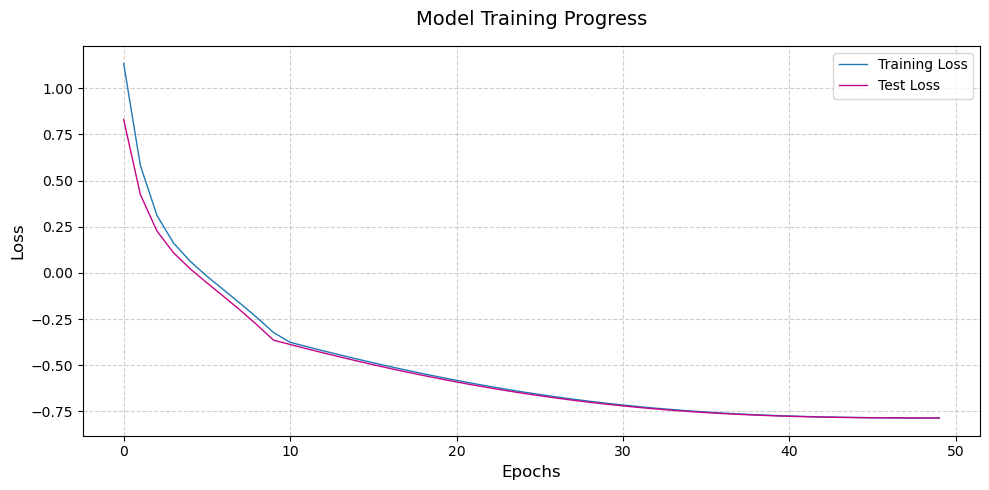

In [34]:
import matplotlib.pyplot as plt

model.eval()
# 1. Set a clean style
plt.style.use("seaborn-v0_8-muted")  # or 'ggplot'
plt.figure(figsize=(10, 5), dpi=100)

# 2. Plot with better aesthetics
plt.plot(
    np.array(history["train_loss"][:]),
    color="#1f77b4",  # A nice professional blue
    linewidth=1,  # Slightly thicker line
    label="Training Loss",
)

plt.plot(
    np.array(history["test_loss"][:]),
    color="#c50488",  # A nice professional blue
    linewidth=1,  # Slightly thicker line
    label="Test Loss",
)


# 3. Add context and labels
plt.title("Model Training Progress", fontsize=14, pad=15)
plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Loss", fontsize=12)

# 4. Clean up the "frame"
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(frameon=True)
plt.tight_layout()
# plt.yscale("log")
plt.show()

In [21]:
# # 1. Set a clean style
# plt.style.use('seaborn-v0_8-muted') # or 'ggplot'
# plt.figure(figsize=(10, 5), dpi=100)

# # 2. Plot with better aesthetics
# plt.plot(-np.array(history["test_loss"][len(history["test_loss"])//4 * 3: ]),
#          color='#1f77b4',       # A nice professional blue
#          linewidth=2,           # Slightly thicker line
#          label='test Loss')

# # 3. Add context and labels
# plt.title('Last forth of test loss', fontsize=14, pad=15)
# plt.xlabel('Epochs', fontsize=12)
# plt.ylabel('Loss', fontsize=12)

# # 4. Clean up the "frame"
# plt.grid(True, linestyle='--', alpha=0.6)
# plt.legend(frameon=True)
# plt.tight_layout()
# plt.yscale("log")
# plt.show()

In [35]:
# import torch


def compute_mmd(x, y, sigma=1.0):
    """
    Computes the Maximum Mean Discrepancy (MMD) between two sets of samples.
    Args:
        x: Tensor of shape [n, d] (Samples from Distribution P)
        y: Tensor of shape [m, d] (Samples from Distribution Q)
        sigma: Bandwidth of the RBF kernel
    """
    # 1. Compute distance matrix (n+m, n+m)
    z = torch.cat([x, y], dim=0)
    # Efficient pairwise distance calculation: ||a-b||^2 = ||a||^2 + ||b||^2 - 2<a,b>
    dist_matrix = torch.cdist(z, z, p=2) ** 2

    # 2. Apply Gaussian Kernel
    kernel_matrix = torch.exp(-dist_matrix / (2 * sigma**2))

    # 3. Extract sub-matrices
    n = x.size(0)
    m = y.size(0)

    k_xx = kernel_matrix[:n, :n]
    k_yy = kernel_matrix[n:, n:]
    k_xy = kernel_matrix[:n, n:]

    # 4. Compute MMD^2 (Unbiased estimator)
    # Subtracting the diagonal (self-distances) for k_xx and k_yy
    mmd2 = (
        (k_xx.sum() - n) / (n * (n - 1))
        + (k_yy.sum() - m) / (m * (m - 1))
        - 2 * k_xy.mean()
    )

    return mmd2


# Example Usage
x = torch.randn(100, 2)  # Mean 0
y = torch.randn(100, 2) + 0.5  # Mean 0.5
loss = compute_mmd(x, y)
print(f"MMD: {loss.item():.4f}")

MMD: 0.0266


AUTOTUNE addmm(128000x29, 128000x256, 256x29)
  bias_addmm 0.3553 ms 100.0% 
  addmm 0.4229 ms 84.0% 
SingleProcess AUTOTUNE benchmarking takes 0.0868 seconds and 0.0002 seconds precompiling for 2 choices


tensor(0.8077)
torch.Size([128000, 3])
Train Set: latent.std(0)=tensor([0.8460, 0.8440, 0.8581])
torch.cov(latent.T)=tensor([[ 0.7157,  0.0341, -0.0120],
        [ 0.0341,  0.7123,  0.0200],
        [-0.0120,  0.0200,  0.7364]])


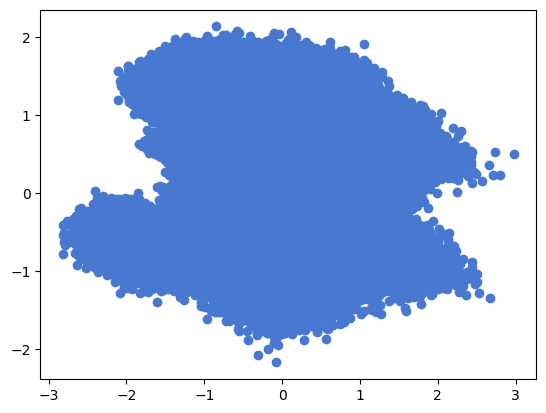

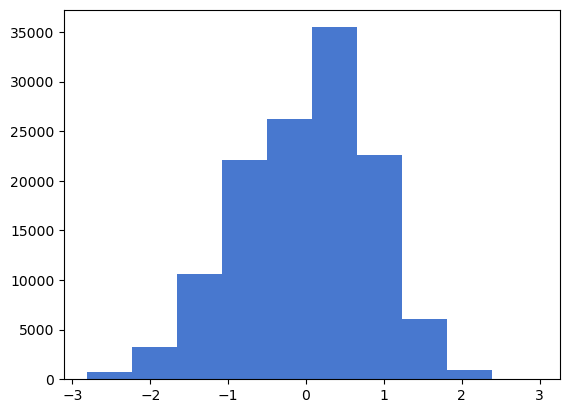

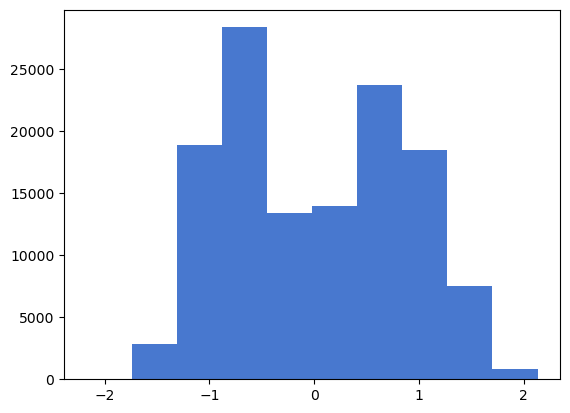

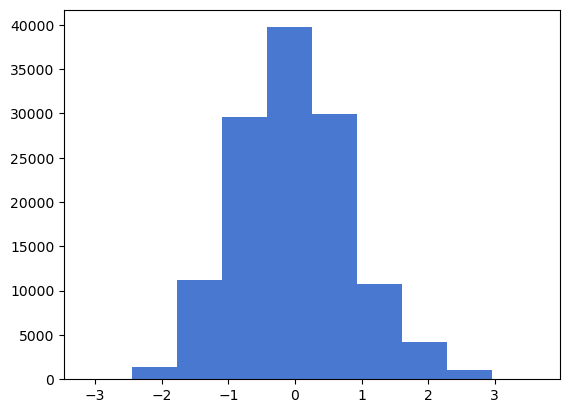

In [36]:
n = 5000
ys = []
xs = []
for (y, x),i in zip(train_loader,range(1000)):
    ys.append(y)
    xs.append(x)

ys= torch.cat(ys,dim=0)
xs = torch.cat(xs,dim=0)


with torch.no_grad():
    latent, log_det = model.forward(
        ys.to(device), xs.to(device).flatten(1)
    )
    latent = latent.cpu() * 7
    print(log_det.mean().cpu())
    print(latent.shape)
    print(f"Train Set: {latent.std(0)=}")
    (print(f"{torch.cov(latent.T)=}"))
    plt.scatter(latent[:, 0], latent[:, 1])
    plt.savefig("latent.png")
    plt.show()
    plt.hist(latent[:, 0])
    plt.show()
    plt.hist(latent[:, 1])
    plt.show()
    plt.hist(latent[:, 2])
    plt.show()

In [24]:
with torch.no_grad():
    latent = model.forward(
        test_tensor_com.to(device), test_tensor_foot.to(device)
    ).cpu()
    print(f"Test Set: {latent.std(0)=}")
    plt.scatter(latent[:, 0], latent[:, 1])
    plt.show()
    plt.hist(latent[:, 0])
    plt.show()
    plt.hist(latent[:, 1])
    plt.show()

NameError: name 'test_tensor_com' is not defined

In [ ]:
# visualize the dataset com
_ = plt.hist(com[:, 0], bins=25)

In [ ]:
res = model.reverse(
    torch.normal(0, 1, (1000, 3)).to(device), train_tensor_foot[:1000].to(device)
)
print(res.shape)

In [ ]:
corrected = res.cpu() * train_com_std + train_com_mean
corrected = corrected.detach()
print(corrected.shape)

In [ ]:
_ = plt.hist(corrected.T, bins=25)
plt.legend(["x", "y", "z"])

In [ ]:
print(com[:1000].shape)
print(corrected.numpy().shape)
plt.hist((com[:1000] - corrected.numpy()).flatten())

In [ ]:
plt.scatter(np.arange(20), corrected[:20, 0])
plt.scatter(np.arange(20), com[:20, 0])
# TODO: copy code from model_realnvp_single.ipynb to visualize confidence

In [ ]:
filename_model_params = "saved_model_test.model"
filename_model_hyperparams = "saved_model_test.def"
torch.save(model.state_dict(), filename_model_params)
model_hyperparams_dict = {
    "input_size": model.realNVP.input_size,
    "condition_size": model.summary.input_size,
    "reduced_condition_size": model.realNVP.condition_size,
    "s_hidden": model.summary.encoder_layers[0].weight.shape[0],
    "s_layers": model.summary.layers,
    "r_hidden": model.realNVP.blocks[0].scale_net[0].weight.shape[0],
    "r_blocks": len(model.realNVP.blocks),
}
torch.save(model_hyperparams_dict, filename_model_hyperparams)

In [ ]:
init_dict = torch.load(filename_model_hyperparams)
print(init_dict)
loaded_dict = torch.load(filename_model_params)
model = RealNVPSummary(**init_dict)
model = torch.compile(model)
model: RealNVPSummary
model.load_state_dict(loaded_dict)